# Resource Estimation of Hamiltonian Simulation of the SYK Model

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle
import numpy as np

df = pd.read_csv("re_data/scale_N_J1_order1.csv")

colors  = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])
markers = cycle(["o", "s", "^", "D", "v", "P", "X", "*", "h", "+"])

type_styles = {
    type_label: {"color": next(colors), "marker": next(markers)}
    for type_label in df["type"].unique()
}

fig, axes = plt.subplots(2, 1, figsize=(9, 10))

rotation_eps = 1e-3

for type_label, group in df.groupby("type"):
    if group["epsilon"].values[0] != "5e-05":
        continue
    style = type_styles[type_label]
    group = group.sort_values("N")
    N_vals          = group["N"].tolist()
    qubit_highwater = group["qubit_highwater"].tolist()
    epsilon_alg = group["epsilon"].values[0]
    total_t_gates   = (group["t_gates"]+group['rotations']*(0.53* np.log2(1/(1 - (1-group['epsilon'])**(1/ group['rotations']))) + 4.86)).tolist()

    kwargs = dict(color=style["color"], marker=style["marker"],
                  linewidth=2, markersize=5, label=type_label)

    axes[0].plot(N_vals, qubit_highwater, **kwargs)
    axes[0].fill_between(N_vals, qubit_highwater, alpha=0.08, color=style["color"])

    axes[1].plot(N_vals, total_t_gates, **kwargs)
    axes[1].fill_between(N_vals, total_t_gates, alpha=0.08, color=style["color"])

axes[0].set_xlabel("N", fontsize=12)
axes[0].set_ylabel("Qubit highwater", fontsize=12)
axes[0].set_title("Qubit highwater vs N", fontsize=13)
axes[0].legend()
axes[0].grid(True, color="gray", alpha=0.2)

axes[1].set_xlabel("N", fontsize=12)
axes[1].set_ylabel("Total T-gates", fontsize=12)
axes[1].set_title("Total T-gates vs N", fontsize=13)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
)
axes[1].legend()
axes[1].grid(True, color="gray", alpha=0.2)

plt.tight_layout(pad=2.0)
plt.show()

ParserError: Error tokenizing data. C error: Expected 10 fields in line 81, saw 11


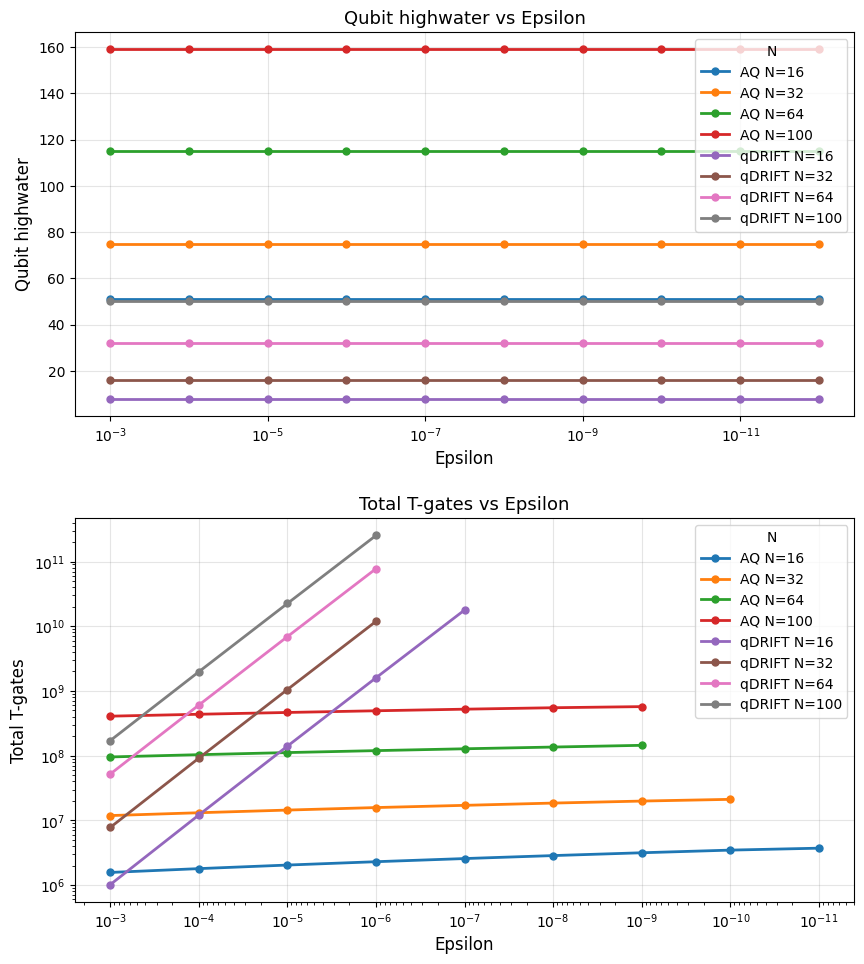

In [2]:
df = pd.read_csv("re_data/scale_eps_J1_order1.csv")

fig, axes = plt.subplots(2, 1, figsize=(9, 10))

# colors = {8: "#378ADD", 16: "#D85A30", 32: "#1D9E75", 64: "#7F77DD", }

for (type_label, N), group in df.groupby(["type", "N"]):
    if N in [8,24,36]:
        continue
    group = group.sort_values("epsilon")
    # color = colors[N]

    axes[0].plot(group["epsilon"], group["qubit_highwater"], #color=color,
                 marker="o", linewidth=2, markersize=5, label=f"{group['type'].values[0]} N={N}")
    
    total_t_gates   = (group["t_gates"]+group['rotations']*(0.53* np.log2(1/(1 - (1-group['epsilon'])**(1/ group['rotations']))) + 4.86))
    
    axes[1].plot(group["epsilon"], total_t_gates,# color=color,
                 marker="o", linewidth=2, markersize=5, label=f"{group['type'].values[0]} N={N}")

# --- Qubit highwater ---
axes[0].set_xscale("log")
axes[0].invert_xaxis()
axes[0].set_xlabel("Epsilon", fontsize=12)
axes[0].set_ylabel("Qubit highwater", fontsize=12)
axes[0].set_title("Qubit highwater vs Epsilon", fontsize=13)
axes[0].legend(title="N")
axes[0].grid(True, color="gray", alpha=0.2)

# --- Total T-gates ---
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].invert_xaxis()
axes[1].set_xlabel("Epsilon", fontsize=12)
axes[1].set_ylabel("Total T-gates", fontsize=12)
axes[1].set_title("Total T-gates vs Epsilon", fontsize=13)
axes[1].legend(title="N")
axes[1].grid(True, color="gray", alpha=0.2)

plt.tight_layout(pad=2.0)
plt.show()